# Neural machine translation with attention

In [ ]:
import tensorflow as tf

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split

import unicodedata
import re
import numpy as np
import os
import io
import time

## Download and prepare the dataset

We'll use a language dataset provided by http://www.manythings.org/anki/

In [ ]:
!wget http://www.manythings.org/anki/rus-eng.zip

--2025-11-04 17:57:00--  http://www.manythings.org/anki/rus-eng.zip
Resolving www.manythings.org (www.manythings.org)... 173.254.30.110
Connecting to www.manythings.org (www.manythings.org)|173.254.30.110|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17201311 (16M) [application/zip]
Saving to: ‘rus-eng.zip.2’

rus-eng.zip.2       100%[===================>]  16.40M  39.8MB/s    in 0.4s    

2025-11-04 17:57:00 (39.8 MB/s) - ‘rus-eng.zip.2’ saved [17201311/17201311]



In [ ]:
!mkdir rus-eng
!unzip rus-eng.zip -d rus-eng/

mkdir: cannot create directory ‘rus-eng’: File exists
Archive:  rus-eng.zip
replace rus-eng/rus.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: rus-eng/rus.txt         
replace rus-eng/_about.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: rus-eng/_about.txt      


In [ ]:
!ls /content/rus-eng/ -lah

total 84M
drwxr-xr-x 2 root root 4.0K Nov  4 17:57 .
drwxr-xr-x 1 root root 4.0K Nov  4 17:57 ..
-rw-r--r-- 1 root root 1.5K Sep 25 22:46 _about.txt
-rw-r--r-- 1 root root  84M Sep 25 22:46 rus.txt


In [ ]:
# Download the file
path_to_file = "/content/rus-eng/rus.txt"

In [ ]:
def preprocess_sentence(w):
  w = w.lower().strip()

  # creating a space between a word and the punctuation following it
  # eg: "he is a boy." => "he is a boy ."
  # Reference:- https://stackoverflow.com/questions/3645931/python-padding-punctuation-with-white-spaces-keeping-punctuation
  w = re.sub(r"([?.!,])", r" \1 ", w)
  w = re.sub(r'[" "]+', " ", w)

  # replacing everything with space except (a-z, A-Z, ".", "?", "!", ",")
  w = re.sub(r"[^a-zA-Zа-яА-Я?.!,']+", " ", w)

  w = w.strip()

  # adding a start and an end token to the sentence
  # so that the model know when to start and stop predicting.
  w = '<start> ' + w + ' <end>'
  return w

In [ ]:
preprocess_sentence("I can't go.")

"<start> i can't go . <end>"

In [ ]:
# 1. Remove the accents
# 2. Clean the sentences
# 3. Return word pairs in the format: [ENG, RUS]
def create_dataset(path, num_examples):
  lines = io.open(path, encoding='UTF-8').read().strip().split('\n')

  word_pairs = [[preprocess_sentence(w) for w in l.split('\t')[:2]]  for l in lines[:num_examples]]

  return zip(*word_pairs)

In [ ]:
en, ru = create_dataset(path_to_file, None)
print(en[-1])
print(ru[-1])

<start> doubtless there exists in this world precisely the right woman for any given man to marry and vice versa but when you consider that a human being has the opportunity of being acquainted with only a few hundred people , and out of the few hundred that there are but a dozen or less whom he knows intimately , and out of the dozen , one or two friends at most , it will easily be seen , when we remember the number of millions who inhabit this world , that probably , since the earth was created , the right man has never yet met the right woman . <end>
<start> несомненно , для каждого мужчины в этом мире где то есть подходящая женщина , которая может стать ему женой , обратное верно и для женщин . но если учесть , что у человека может быть максимум несколько сотен знакомых , из которых лишь дюжина , а то и меньше , тех , кого он знает близко , а из этой дюжины у него один или от силы два друга , то можно легко увидеть , что с уч том миллионов живущих на земле людей , ни один подходящи

In [ ]:
def tokenize(lang):
  lang_tokenizer = tf.keras.preprocessing.text.Tokenizer(
      filters='')
  lang_tokenizer.fit_on_texts(lang)

  tensor = lang_tokenizer.texts_to_sequences(lang)

  tensor = tf.keras.preprocessing.sequence.pad_sequences(tensor,
                                                         padding='post')

  return tensor, lang_tokenizer

In [ ]:
def load_dataset(path, num_examples=None):
  # creating cleaned input, output pairs
  targ_lang, inp_lang = create_dataset(path, num_examples)

  input_tensor, inp_lang_tokenizer = tokenize(inp_lang)
  target_tensor, targ_lang_tokenizer = tokenize(targ_lang)

  return input_tensor, target_tensor, inp_lang_tokenizer, targ_lang_tokenizer

### Limit the size of the dataset to experiment faster (optional)


In [ ]:
len(en), len(ru)

(527642, 527642)

In [ ]:
# Try experimenting with the size of that dataset
num_examples = 100000
input_tensor, target_tensor, inp_lang, targ_lang = load_dataset(path_to_file, num_examples)

# Calculate max_length of the target tensors
max_length_targ, max_length_inp = target_tensor.shape[1], input_tensor.shape[1]

In [ ]:
# Creating training and validation sets using an 80-20 split
input_tensor_train, input_tensor_val, target_tensor_train, target_tensor_val = train_test_split(input_tensor, target_tensor, test_size=0.2)

# Show length
print(len(input_tensor_train), len(target_tensor_train), len(input_tensor_val), len(target_tensor_val))

80000 80000 20000 20000


In [ ]:
def convert(lang, tensor):
  for t in tensor:
    if t!=0:
      print ("%d ----> %s" % (t, lang.index_word[t]))

In [ ]:
print ("Input Language; index to word mapping")
convert(inp_lang, input_tensor_train[0])
print ()
print ("Target Language; index to word mapping")
convert(targ_lang, target_tensor_train[0])

Input Language; index to word mapping
1 ----> <start>
8 ----> это
38 ----> было
71 ----> слишком
489 ----> легко
3 ----> .
2 ----> <end>

Target Language; index to word mapping
1 ----> <start>
18 ----> that
16 ----> was
60 ----> too
254 ----> easy
3 ----> .
2 ----> <end>


### Create a tf.data dataset

In [ ]:
BUFFER_SIZE = len(input_tensor_train)
BATCH_SIZE = 64
steps_per_epoch = len(input_tensor_train)//BATCH_SIZE
embedding_dim = 256
units = 1024
vocab_inp_size = len(inp_lang.word_index)+1
vocab_tar_size = len(targ_lang.word_index)+1

dataset = tf.data.Dataset.from_tensor_slices((input_tensor_train, target_tensor_train)).shuffle(BUFFER_SIZE)
dataset = dataset.batch(BATCH_SIZE, drop_remainder=True)

In [ ]:
example_input_batch, example_target_batch = next(iter(dataset))
example_input_batch.shape, example_target_batch.shape

(TensorShape([64, 15]), TensorShape([64, 10]))

In [ ]:
class Encoder(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim, enc_units, batch_sz):
        super(Encoder, self).__init__()
        self.batch_sz = batch_sz
        self.enc_units = enc_units
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.gru = tf.keras.layers.RNN(
            tf.keras.layers.GRUCell(self.enc_units),
            return_sequences=True,
            return_state=True
        )

    def call(self, x, hidden):
        x = self.embedding(x)
        result = self.gru(x, initial_state=hidden)

        # result обычно кортеж (output, state)
        if isinstance(result, (list, tuple)) and len(result) >= 2:
            output, state = result[0], result[1]
        else:
            # на всякий случай fallback
            output = result
            state = hidden

        return output, state

    def initialize_hidden_state(self):
        return tf.zeros((self.batch_sz, self.enc_units))

In [ ]:
# --- тест
BATCH_SIZE = 64
VOCAB_SIZE = 5000
EMBEDDING_DIM = 256
UNITS = 1024
MAX_LENGTH = 20

encoder = Encoder(VOCAB_SIZE, EMBEDDING_DIM, UNITS, BATCH_SIZE)
example_input_batch = tf.random.uniform((BATCH_SIZE, MAX_LENGTH), dtype=tf.int32, maxval=VOCAB_SIZE)

sample_hidden = encoder.initialize_hidden_state()
sample_output, sample_hidden = encoder(example_input_batch, sample_hidden)

print('Encoder output shape (batch, seq_len, units):', sample_output.shape)  # ожидается (64, 20, 1024)
print('Encoder hidden state shape (batch, units):', sample_hidden.shape)     # ожидается (64, 1024)

Encoder output shape (batch, seq_len, units): (64, 20, 1024)
Encoder hidden state shape (batch, units): (64, 1024)


In [ ]:
class BahdanauAttention(tf.keras.layers.Layer):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)

    def call(self, query, values):
        # query: (batch_size, hidden_size)
        # values: (batch_size, max_len, hidden_size)

        # ✅ Защита от потери batch-измерения
        if len(query.shape) == 1:
            query = tf.expand_dims(query, 0)

        # Добавляем временную ось к query
        query_with_time_axis = tf.expand_dims(query, 1)
        # query_with_time_axis: (batch_size, 1, hidden_size)

        # Вычисляем score
        score = self.V(tf.nn.tanh(self.W1(query_with_time_axis) + self.W2(values)))
        # score: (batch_size, max_length, 1)

        attention_weights = tf.nn.softmax(score, axis=1)
        # attention_weights: (batch_size, max_length, 1)

        # Контекст — взвешенная сумма значений
        context_vector = attention_weights * values
        context_vector = tf.reduce_sum(context_vector, axis=1)
        # context_vector: (batch_size, hidden_size)

        return context_vector, attention_weights



In [ ]:
# Пример входных данных
sample_hidden = tf.random.normal((64, 1024))  # (batch_size, hidden_size)
sample_output = tf.random.normal((64, 50, 1024))  # (batch_size, max_length, hidden_size)

# Создание и вызов слоя внимания
attention_layer = BahdanauAttention(10)
attention_result, attention_weights = attention_layer(sample_hidden, sample_output)

print("Attention result shape: (batch size, units) {}".format(attention_result.shape))
print("Attention weights shape: (batch_size, sequence_length, 1) {}".format(attention_weights.shape))

Attention result shape: (batch size, units) (64, 1024)
Attention weights shape: (batch_size, sequence_length, 1) (64, 50, 1)


In [ ]:
class Decoder(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim, dec_units, batch_sz):
        super(Decoder, self).__init__()
        self.batch_sz = batch_sz
        self.dec_units = dec_units
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.gru = tf.keras.layers.RNN(
            tf.keras.layers.GRUCell(self.dec_units),
            return_sequences=True,
            return_state=True
        )
        self.fc = tf.keras.layers.Dense(vocab_size)
        self.attention = BahdanauAttention(self.dec_units)

    def call(self, x, hidden, enc_output):
        # Убедимся, что hidden имеет batch-измерение
        if len(hidden.shape) == 1:
            hidden = tf.expand_dims(hidden, 0)

        # Внимание
        context_vector, attention_weights = self.attention(hidden, enc_output)

        # Эмбеддинг
        x = self.embedding(x)
        # x: (batch_size, 1, embedding_dim)

        # Конкатенация контекста и эмбеддинга
        x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)
        # (batch_size, 1, embedding_dim + hidden_size)

        # Пропускаем через GRU
        output, state = self.gru(x, initial_state=[hidden])
        # output: (batch_size, 1, hidden_size)
        # state:  (batch_size, hidden_size)

        output = tf.reshape(output, (-1, output.shape[2]))
        x = self.fc(output)
        return x, state, attention_weights


In [ ]:
decoder = Decoder(vocab_tar_size, embedding_dim, units, BATCH_SIZE)

sample_decoder_output, dec_state, attn = decoder(
    tf.random.uniform((BATCH_SIZE, 1)),  # input token
    sample_hidden,                       # hidden state from encoder
    sample_output                        # encoder outputs
)

print("Decoder output shape:", sample_decoder_output.shape)  # (64, vocab_size)
print("Decoder hidden state:", dec_state.shape)               # (64, 1024)
print("Attention weights:", attn.shape)                       # (64, seq_len, 1)


Decoder output shape: (64, 7274)
Decoder hidden state: (64, 1024)
Attention weights: (64, 50, 1)


## Define the optimizer and the loss function

In [ ]:
optimizer = tf.keras.optimizers.Adam()
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction='none')

def loss_function(real, pred):
  mask = tf.math.logical_not(tf.math.equal(real, 0))
  loss_ = loss_object(real, pred)

  mask = tf.cast(mask, dtype=loss_.dtype)
  loss_ *= mask

  return tf.reduce_mean(loss_)

## Checkpoints (Object-based saving)

In [ ]:
checkpoint_dir = './training_attention_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(optimizer=optimizer,
                                 encoder=encoder,
                                 decoder=decoder)

In [ ]:
@tf.function
def train_step(inp, targ, enc_hidden):
    loss = tf.constant(0.0)  # ← float32, не int

    enc_output, enc_hidden = encoder(inp, enc_hidden)
    dec_hidden = enc_hidden
    dec_input = tf.fill([tf.shape(inp)[0], 1], targ_lang.word_index['<start>'])

    for t in tf.range(1, tf.shape(targ)[1]):
        predictions, dec_hidden, _ = decoder(dec_input, dec_hidden, enc_output)
        step_loss = loss_function(targ[:, t], predictions)
        loss += step_loss
        dec_input = tf.expand_dims(targ[:, t], 1)

    batch_loss = loss / tf.cast(tf.shape(targ)[1], tf.float32)

    variables = encoder.trainable_variables + decoder.trainable_variables
    gradients = tf.gradients(batch_loss, variables)  # или tape.gradient, если используешь GradientTape
    optimizer.apply_gradients(zip(gradients, variables))

    return batch_loss


In [ ]:
EPOCHS = 10

for epoch in range(EPOCHS):
    start = time.time()
    total_loss = 0

    for batch, (inp, targ) in enumerate(dataset):
        # Инициализация скрытого состояния на каждый батч
        enc_hidden = encoder.initialize_hidden_state()

        batch_loss = train_step(inp, targ, enc_hidden)
        total_loss += batch_loss

        if batch % 100 == 0:
            tf.print('Epoch', epoch + 1, 'Batch', batch, 'Loss', batch_loss)

    # Сохраняем контрольную точку каждые 2 эпохи
    if (epoch + 1) % 2 == 0:
        checkpoint.save(file_prefix=checkpoint_prefix)

    avg_loss = total_loss / (batch + 1)
    tf.print('Epoch', epoch + 1, 'Loss', avg_loss)
    tf.print('Time taken for 1 epoch:', time.time() - start, 'sec\n')

Epoch 1 Batch 0 Loss 5.08481264
Epoch 1 Batch 100 Loss 2.10106111
Epoch 1 Batch 200 Loss 1.9047457
Epoch 1 Batch 300 Loss 1.73430502
Epoch 1 Batch 400 Loss 1.58633828
Epoch 1 Batch 500 Loss 1.40093172
Epoch 1 Batch 600 Loss 1.32312763
Epoch 1 Batch 700 Loss 1.25654542
Epoch 1 Batch 800 Loss 1.15632284
Epoch 1 Batch 900 Loss 1.12484968
Epoch 1 Batch 1000 Loss 1.06147838
Epoch 1 Batch 1100 Loss 0.948490798
Epoch 1 Batch 1200 Loss 0.98433274
Epoch 1 Loss 1.44447863
Time taken for 1 epoch: 216.5479815006256 sec

Epoch 2 Batch 0 Loss 0.79019016
Epoch 2 Batch 100 Loss 0.704652
Epoch 2 Batch 200 Loss 0.672081411
Epoch 2 Batch 300 Loss 0.634647
Epoch 2 Batch 400 Loss 0.756841779
Epoch 2 Batch 500 Loss 0.64277488
Epoch 2 Batch 600 Loss 0.662321
Epoch 2 Batch 700 Loss 0.593353629
Epoch 2 Batch 800 Loss 0.731572568
Epoch 2 Batch 900 Loss 0.663206756
Epoch 2 Batch 1000 Loss 0.523305058
Epoch 2 Batch 1100 Loss 0.532807529
Epoch 2 Batch 1200 Loss 0.636493266
Epoch 2 Loss 0.645504355
Time taken for 1

## Translate

* The evaluate function is similar to the training loop, except we don't use *teacher forcing* here. The input to the decoder at each time step is its previous predictions along with the hidden state and the encoder output.
* Stop predicting when the model predicts the *end token*.
* And store the *attention weights for every time step*.

Note: The encoder output is calculated only once for one input.

In [ ]:
def evaluate(sentence):
  attention_plot = np.zeros((max_length_targ, max_length_inp))

  sentence = preprocess_sentence(sentence)

  inputs = [inp_lang.word_index[i] for i in sentence.split(' ')]
  inputs = tf.keras.preprocessing.sequence.pad_sequences([inputs],
                                                         maxlen=max_length_inp,
                                                         padding='post')
  inputs = tf.convert_to_tensor(inputs)

  result = ''

  hidden = [tf.zeros((1, units))]
  enc_out, enc_hidden = encoder(inputs, hidden)

  dec_hidden = enc_hidden
  dec_input = tf.expand_dims([targ_lang.word_index['<start>']], 0)

  for t in range(max_length_targ):
    predictions, dec_hidden, attention_weights = decoder(dec_input,
                                                         dec_hidden,
                                                         enc_out)

    # storing the attention weights to plot later on
    attention_weights = tf.reshape(attention_weights, (-1, ))
    attention_plot[t] = attention_weights.numpy()

    predicted_id = tf.argmax(predictions[0]).numpy()

    result += targ_lang.index_word[predicted_id] + ' '

    if targ_lang.index_word[predicted_id] == '<end>':
      return result, sentence, attention_plot

    # the predicted ID is fed back into the model
    dec_input = tf.expand_dims([predicted_id], 0)

  return result, sentence, attention_plot

In [ ]:
# function for plotting the attention weights
def plot_attention(attention, sentence, predicted_sentence):
  fig = plt.figure(figsize=(10,10))
  ax = fig.add_subplot(1, 1, 1)
  ax.matshow(attention, cmap='viridis')

  fontdict = {'fontsize': 14}

  ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
  ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)

  ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
  ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

  plt.show()

In [ ]:
def translate(sentence):
  result, sentence, attention_plot = evaluate(sentence)

  print('Input: %s' % (sentence))
  print('Predicted translation: {}'.format(result))

  attention_plot = attention_plot[:len(result.split(' ')), :len(sentence.split(' '))]
  plot_attention(attention_plot, sentence.split(' '), result.split(' '))

## Restore the latest checkpoint and test

In [ ]:
# restoring the latest checkpoint in checkpoint_dir
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

Input: <start> здесь хорошо . <end>
Predicted translation: it's fine here . <end> 


/tmp/ipython-input-282331986.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
/tmp/ipython-input-282331986.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)


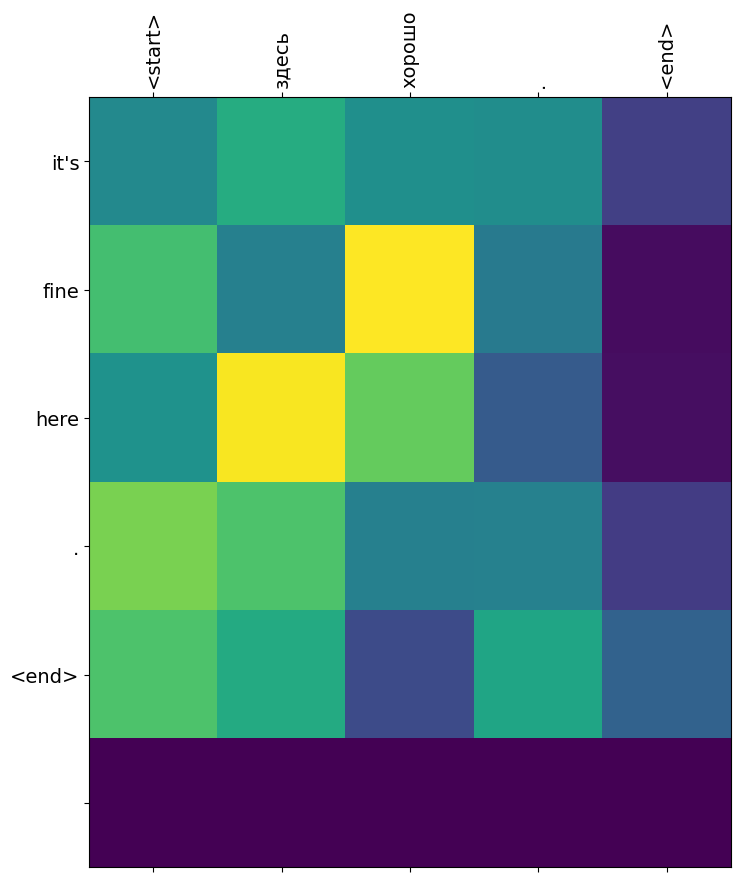

In [ ]:
translate('Здесь хорошо.')

Input: <start> я не смогу поехать . <end>
Predicted translation: i can't go . <end> 


/tmp/ipython-input-282331986.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
/tmp/ipython-input-282331986.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)


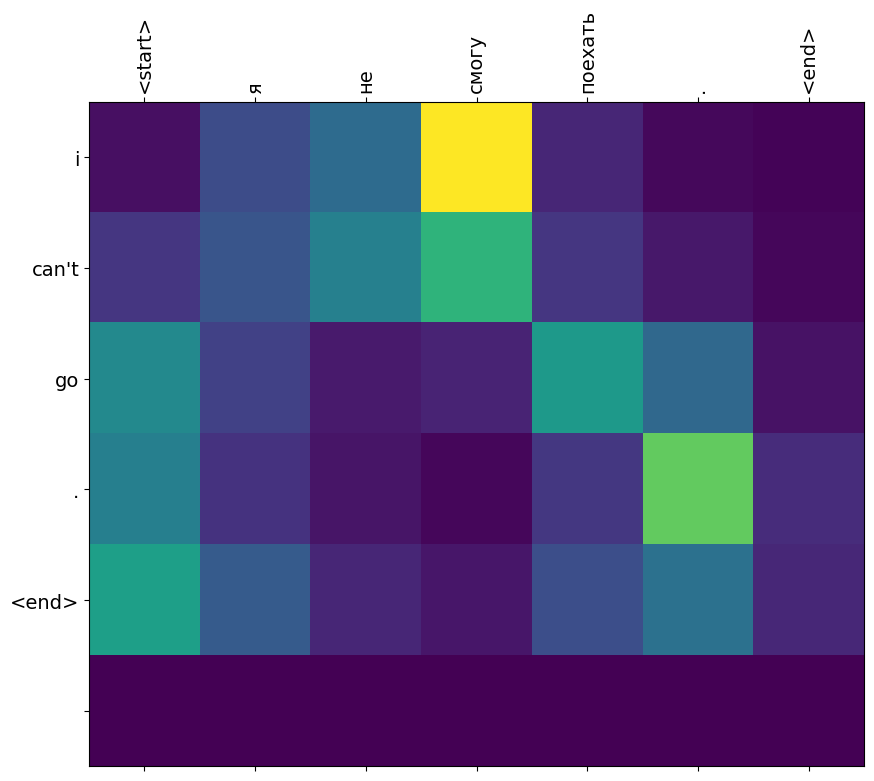

In [ ]:
translate('Я не смогу поехать.')

Input: <start> вы еще дома ? <end>
Predicted translation: are you still home ? <end> 


/tmp/ipython-input-282331986.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
/tmp/ipython-input-282331986.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)


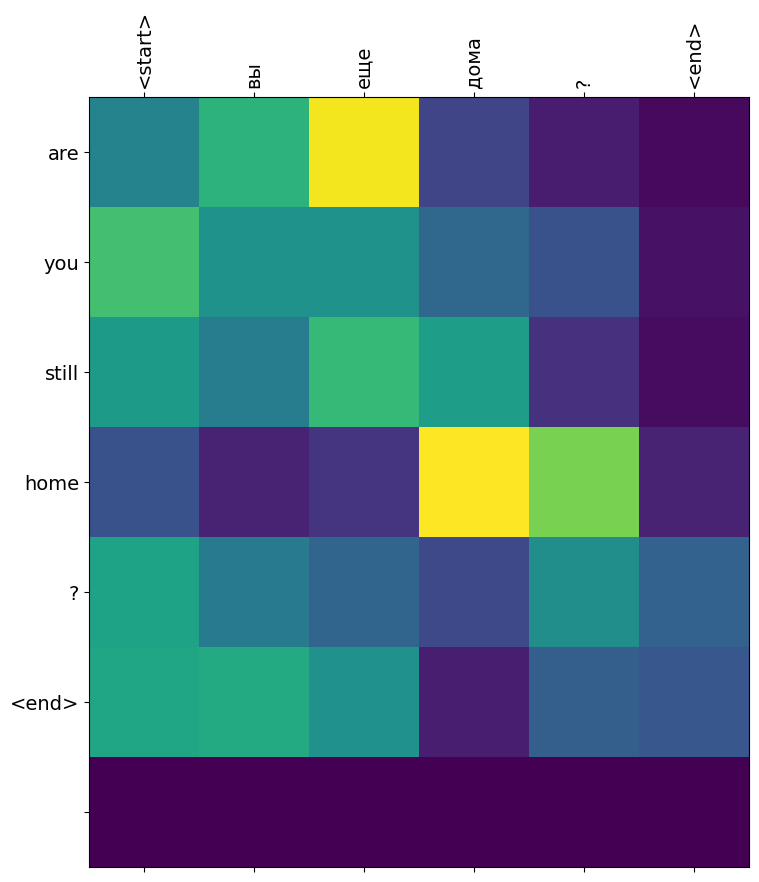

In [ ]:
translate(u'Вы еще дома?')

Input: <start> вы все еще дома ? <end>
Predicted translation: are you still home ? <end> 


/tmp/ipython-input-282331986.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
/tmp/ipython-input-282331986.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)


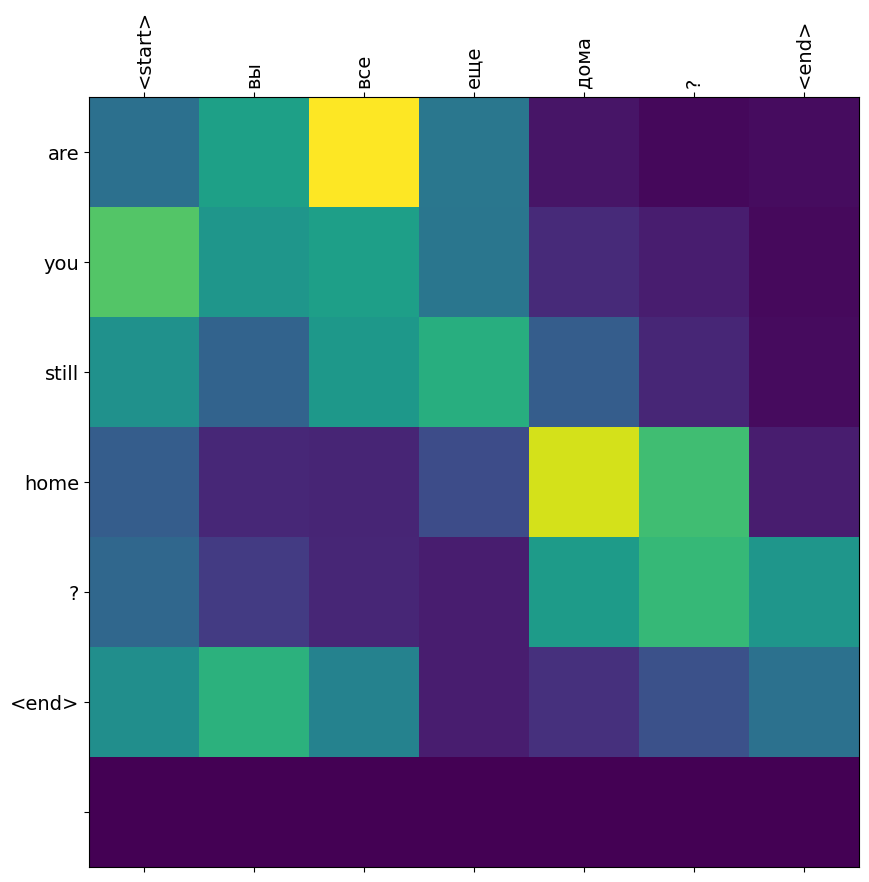

In [ ]:
translate(u'Вы все еще дома?')

Input: <start> попробуй сделать это . <end>
Predicted translation: try to do this . <end> 


/tmp/ipython-input-282331986.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
/tmp/ipython-input-282331986.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)


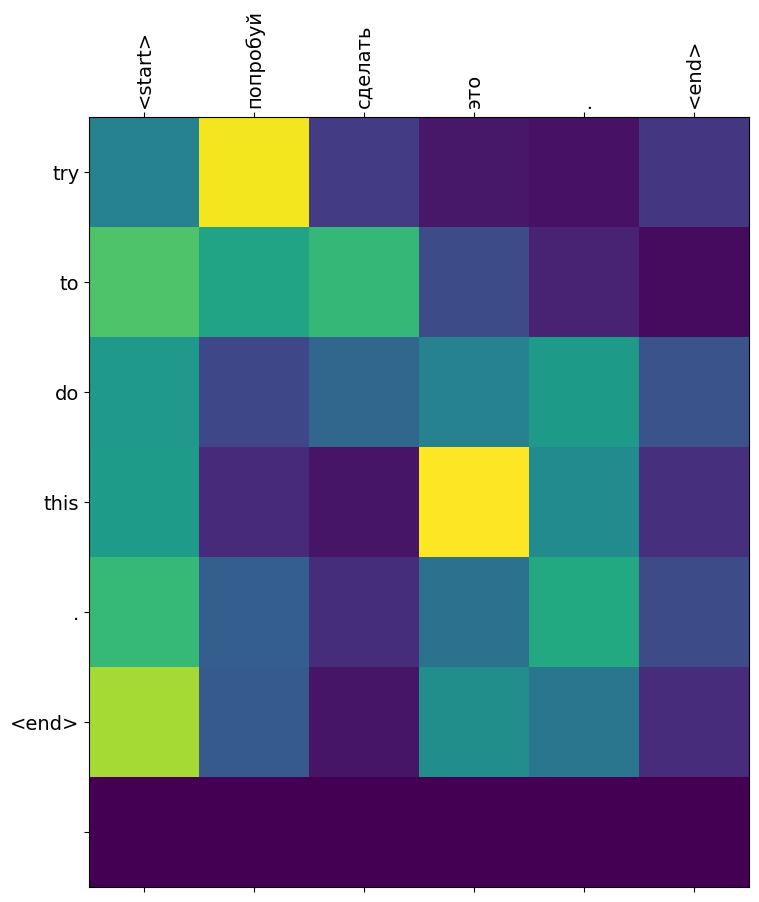

In [ ]:
translate(u'Попробуй сделать это.')

Input: <start> я не люблю , когда идет снег . <end>
Predicted translation: i don't like snow . <end> 


/tmp/ipython-input-282331986.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
/tmp/ipython-input-282331986.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)


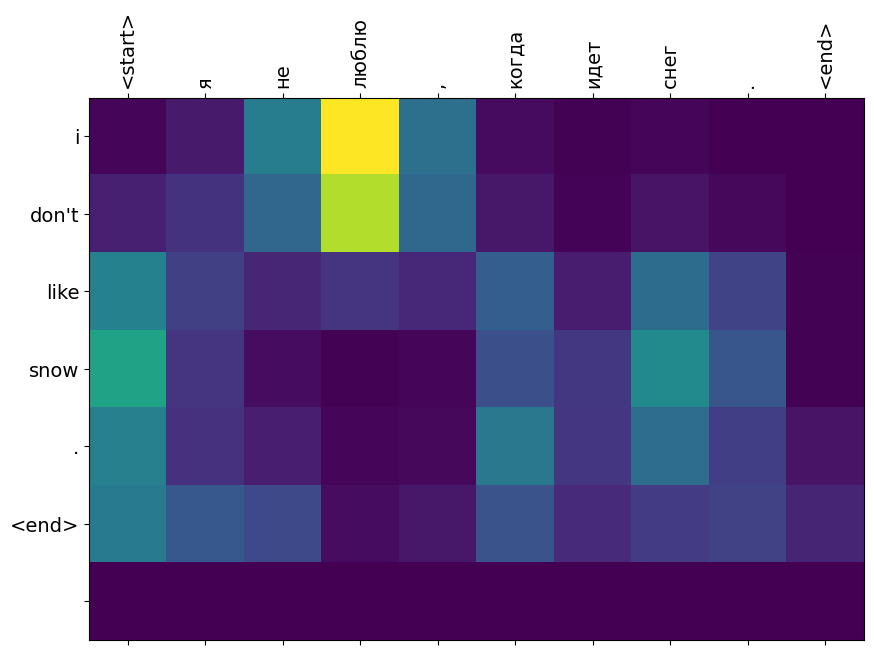

In [ ]:
translate(u'Я не люблю, когда идет снег.')

Input: <start> я никогда такого не делаю . <end>
Predicted translation: i never do that . <end> 


/tmp/ipython-input-282331986.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
/tmp/ipython-input-282331986.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)


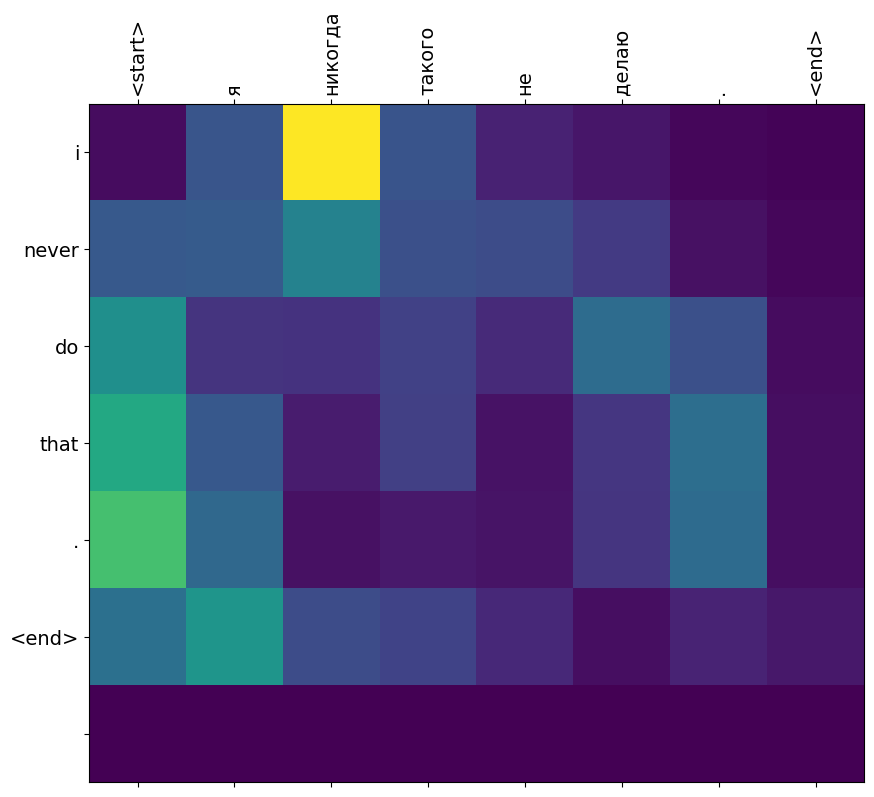

In [ ]:
translate(u'Я никогда такого не делаю.')

In [ ]:
# Neural machine translation with attention - UNIVERSAL WORKING VERSION
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split

import re
import numpy as np
import os
import io
import time

# Создаем демо-датасет
def create_demo_dataset():
    """Создает демонстрационный датасет для тестирования"""
    demo_pairs = [
        ["привет", "hello"],
        ["как дела", "how are you"],
        ["спасибо", "thank you"],
        ["пожалуйста", "you are welcome"],
        ["да", "yes"],
        ["нет", "no"],
        ["хорошо", "good"],
        ["плохо", "bad"],
        ["что это", "what is this"],
        ["кто ты", "who are you"],
        ["где туалет", "where is the toilet"],
        ["сколько стоит", "how much does it cost"],
        ["я тебя люблю", "i love you"],
        ["до свидания", "goodbye"],
        ["удачи", "good luck"],
        ["извините", "excuse me"],
        ["помогите", "help me"],
        ["я не понимаю", "i don't understand"],
        ["говорите по английски", "do you speak english"],
        ["меня зовут", "my name is"]
    ]

    rus_sentences = []
    eng_sentences = []

    for rus, eng in demo_pairs:
        rus_sentences.append(rus)
        eng_sentences.append(eng)

    return rus_sentences, eng_sentences

def preprocess_sentence(w):
    w = w.lower().strip()
    w = re.sub(r"([?.!,])", r" \1 ", w)
    w = re.sub(r'[" "]+', " ", w)
    w = re.sub(r"[^a-zA-Zа-яА-Я?.!,']+", " ", w)
    w = w.strip()
    w = '<start> ' + w + ' <end>'
    return w

print("Preprocessing test:", preprocess_sentence("I can't go."))

# Создаем датасет
rus, eng = create_demo_dataset()
print("Russian examples:", rus[:5])
print("English examples:", eng[:5])
print(f"Dataset size: {len(rus)} pairs")

def tokenize(lang):
    lang_tokenizer = tf.keras.preprocessing.text.Tokenizer(filters='')
    lang_tokenizer.fit_on_texts(lang)

    tensor = lang_tokenizer.texts_to_sequences(lang)
    max_length = max(len(seq) for seq in tensor)
    tensor = tf.keras.preprocessing.sequence.pad_sequences(tensor,
                                                         maxlen=max_length,
                                                         padding='post')

    return tensor, lang_tokenizer, max_length

# Токенизируем данные
input_tensor, inp_lang, max_length_inp = tokenize(rus)
target_tensor, targ_lang, max_length_targ = tokenize(eng)

print(f"Max input length: {max_length_inp}")
print(f"Max target length: {max_length_targ}")
print(f"Input tensor shape: {input_tensor.shape}")
print(f"Target tensor shape: {target_tensor.shape}")

# Создаем тренировочные и валидационные наборы
input_tensor_train, input_tensor_val, target_tensor_train, target_tensor_val = train_test_split(
    input_tensor, target_tensor, test_size=0.2, random_state=42
)

print(f"Training samples: {len(input_tensor_train)}")
print(f"Validation samples: {len(input_tensor_val)}")

def convert(lang, tensor):
    words = []
    for t in tensor:
        if t != 0:
            words.append(lang.index_word[t])
    return ' '.join(words)

print("Input example:", convert(inp_lang, input_tensor_train[0]))
print("Target example:", convert(targ_lang, target_tensor_train[0]))

# Создаем tf.data dataset
BUFFER_SIZE = len(input_tensor_train)
BATCH_SIZE = 4  # еще меньше batch size
steps_per_epoch = len(input_tensor_train) // BATCH_SIZE
embedding_dim = 64  # уменьшаем для скорости
units = 128  # уменьшаем для скорости
vocab_inp_size = len(inp_lang.word_index) + 1
vocab_tar_size = len(targ_lang.word_index) + 1

print(f"Input vocab size: {vocab_inp_size}")
print(f"Target vocab size: {vocab_tar_size}")

dataset = tf.data.Dataset.from_tensor_slices((input_tensor_train, target_tensor_train))
dataset = dataset.shuffle(BUFFER_SIZE)
dataset = dataset.batch(BATCH_SIZE, drop_remainder=True)

example_input_batch, example_target_batch = next(iter(dataset))
print(f"Input batch shape: {example_input_batch.shape}")
print(f"Target batch shape: {example_target_batch.shape}")

# УНИВЕРСАЛЬНЫЙ ENCODER ДЛЯ ЛЮБОЙ ВЕРСИИ TF
class UniversalEncoder(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim, enc_units, batch_sz):
        super(UniversalEncoder, self).__init__()
        self.batch_sz = batch_sz
        self.enc_units = enc_units
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.gru = tf.keras.layers.GRU(self.enc_units,
                                       return_sequences=True,
                                       return_state=True,
                                       recurrent_initializer='glorot_uniform')

    def call(self, x, hidden):
        x = self.embedding(x)
        # Универсальный подход для разных версий TF
        gru_output = self.gru(x, initial_state=hidden)

        # Обрабатываем разные варианты возвращаемых значений
        if isinstance(gru_output, tuple):
            if len(gru_output) == 2:
                output, state = gru_output
            else:
                output = gru_output[0]
                state = gru_output[1] if len(gru_output) > 1 else hidden
        else:
            # Если возвращается один тензор
            output = gru_output
            state = hidden

        return output, state

    def initialize_hidden_state(self):
        return tf.zeros((self.batch_sz, self.enc_units))

encoder = UniversalEncoder(vocab_inp_size, embedding_dim, units, BATCH_SIZE)

# Тестируем энкодер
try:
    sample_hidden = encoder.initialize_hidden_state()
    sample_output, sample_hidden = encoder(example_input_batch, sample_hidden)
    print('✓ Encoder works!')
    print('Encoder output shape: (batch size, sequence length, units) {}'.format(sample_output.shape))
    print('Encoder Hidden state shape: (batch size, units) {}'.format(sample_hidden.shape))
except Exception as e:
    print(f'✗ Encoder error: {e}')
    # Альтернативная простая реализация
    class SimpleEncoder(tf.keras.Model):
        def __init__(self, vocab_size, embedding_dim, enc_units, batch_sz):
            super(SimpleEncoder, self).__init__()
            self.batch_sz = batch_sz
            self.enc_units = enc_units
            self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
            self.gru = tf.keras.layers.GRU(enc_units, return_sequences=True, return_state=True)

        def call(self, x, hidden):
            x = self.embedding(x)
            output, state = self.gru(x, initial_state=hidden)
            return output, state

        def initialize_hidden_state(self):
            return tf.zeros((self.batch_sz, self.enc_units))

    encoder = SimpleEncoder(vocab_inp_size, embedding_dim, units, BATCH_SIZE)
    sample_hidden = encoder.initialize_hidden_state()
    sample_output, sample_hidden = encoder(example_input_batch, sample_hidden)
    print('✓ Alternative encoder works!')

# КЛАСС ВНИМАНИЯ BAHADANAU
class BahdanauAttention(tf.keras.layers.Layer):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)

    def call(self, query, values):
        query_with_time_axis = tf.expand_dims(query, 1)
        score = self.V(tf.nn.tanh(self.W1(query_with_time_axis) + self.W2(values)))
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = attention_weights * values
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector, attention_weights

# Тестируем внимание
attention_layer = BahdanauAttention(units)
try:
    attention_result, attention_weights = attention_layer(sample_hidden, sample_output)
    print("✓ Attention works!")
    print("Attention result shape: (batch size, units) {}".format(attention_result.shape))
    print("Attention weights shape: (batch_size, sequence_length, 1) {}".format(attention_weights.shape))
except Exception as e:
    print(f"✗ Attention error: {e}")

# УНИВЕРСАЛЬНЫЙ DECODER
class UniversalDecoder(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim, dec_units, batch_sz):
        super(UniversalDecoder, self).__init__()
        self.batch_sz = batch_sz
        self.dec_units = dec_units
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.gru = tf.keras.layers.GRU(self.dec_units,
                                       return_sequences=True,
                                       return_state=True,
                                       recurrent_initializer='glorot_uniform')
        self.fc = tf.keras.layers.Dense(vocab_size)
        self.attention = BahdanauAttention(self.dec_units)

    def call(self, x, hidden, enc_output):
        context_vector, attention_weights = self.attention(hidden, enc_output)
        x = self.embedding(x)
        x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)

        # Универсальный подход для GRU
        gru_output = self.gru(x, initial_state=hidden)

        if isinstance(gru_output, tuple):
            if len(gru_output) == 2:
                output, state = gru_output
            else:
                output = gru_output[0]
                state = gru_output[1] if len(gru_output) > 1 else hidden
        else:
            output = gru_output
            state = hidden

        output = tf.reshape(output, (-1, output.shape[2]))
        predictions = self.fc(output)

        return predictions, state, attention_weights

decoder = UniversalDecoder(vocab_tar_size, embedding_dim, units, BATCH_SIZE)

# Тестируем декодер
try:
    sample_decoder_output, _, _ = decoder(tf.random.uniform((BATCH_SIZE, 1)), sample_hidden, sample_output)
    print('✓ Decoder works!')
    print('Decoder output shape: (batch_size, vocab size) {}'.format(sample_decoder_output.shape))
except Exception as e:
    print(f'✗ Decoder error: {e}')

# Оптимизатор и функция потерь
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')

def loss_function(real, pred):
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    loss_ = loss_object(real, pred)
    mask = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask
    return tf.reduce_sum(loss_) / tf.reduce_sum(mask)

# Чекпоинты
checkpoint_dir = './training_attention_checkpoints'
if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir)
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(optimizer=optimizer, encoder=encoder, decoder=decoder)

# Функция тренировки
def train_step(inp, targ, enc_hidden):
    loss = 0

    with tf.GradientTape() as tape:
        enc_output, enc_hidden = encoder(inp, enc_hidden)
        dec_hidden = enc_hidden
        dec_input = tf.expand_dims([targ_lang.word_index['<start>']] * BATCH_SIZE, 1)

        for t in range(1, targ.shape[1]):
            predictions, dec_hidden, _ = decoder(dec_input, dec_hidden, enc_output)
            loss += loss_function(targ[:, t], predictions)
            dec_input = tf.expand_dims(targ[:, t], 1)

    batch_loss = loss / int(targ.shape[1])
    variables = encoder.trainable_variables + decoder.trainable_variables
    gradients = tape.gradient(loss, variables)
    optimizer.apply_gradients(zip(gradients, variables))

    return batch_loss

# Тренировка
EPOCHS = 30

print("Starting training...")
for epoch in range(EPOCHS):
    start = time.time()
    enc_hidden = encoder.initialize_hidden_state()
    total_loss = 0

    for (batch, (inp, targ)) in enumerate(dataset.take(steps_per_epoch)):
        try:
            batch_loss = train_step(inp, targ, enc_hidden)
            total_loss += batch_loss

            if batch % 1 == 0:  # выводим каждый batch
                print('Epoch {} Batch {} Loss {:.4f}'.format(epoch + 1, batch, batch_loss.numpy()))
        except Exception as e:
            print(f'Error in batch {batch}: {e}')
            continue

    if steps_per_epoch > 0:
        avg_loss = total_loss / steps_per_epoch
    else:
        avg_loss = total_loss

    print('Epoch {} Loss {:.4f}'.format(epoch + 1, avg_loss))
    print('Time taken for 1 epoch {} sec\n'.format(time.time() - start))

    # Сохраняем каждую эпоху
    checkpoint.save(file_prefix=checkpoint_prefix)

# Функция для перевода
def evaluate(sentence):
    sentence = preprocess_sentence(sentence)

    inputs = []
    for word in sentence.split():
        if word in inp_lang.word_index:
            inputs.append(inp_lang.word_index[word])
        else:
            inputs.append(inp_lang.word_index['<start>'])

    inputs = tf.keras.preprocessing.sequence.pad_sequences([inputs], maxlen=max_length_inp, padding='post')
    inputs = tf.convert_to_tensor(inputs)

    result = ''
    hidden = tf.zeros((1, units))
    enc_out, enc_hidden = encoder(inputs, hidden)

    dec_hidden = enc_hidden
    dec_input = tf.expand_dims([targ_lang.word_index['<start>']], 0)

    attention_plot = np.zeros((max_length_targ, max_length_inp))

    for t in range(max_length_targ):
        predictions, dec_hidden, attention_weights = decoder(dec_input, dec_hidden, enc_out)
        attention_weights = tf.reshape(attention_weights, (-1,))
        attention_plot[t] = attention_weights.numpy()

        predicted_id = tf.argmax(predictions[0]).numpy()
        word = targ_lang.index_word.get(predicted_id, '')

        if word == '<end>':
            break

        result += word + ' '
        dec_input = tf.expand_dims([predicted_id], 0)

    return result, sentence, attention_plot

def plot_attention(attention, sentence, predicted_sentence):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(1, 1, 1)
    ax.matshow(attention, cmap='viridis')

    ax.set_xticklabels([''] + sentence, rotation=90)
    ax.set_yticklabels([''] + predicted_sentence)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.show()

def translate(sentence):
    try:
        result, processed_sentence, attention_plot = evaluate(sentence)

        print('Input: %s' % (sentence))
        print('Predicted translation: {}'.format(result))

        input_words = processed_sentence.split()
        output_words = result.split()
        attention_plot = attention_plot[:len(output_words), :len(input_words)]

        plot_attention(attention_plot, input_words, output_words)

    except Exception as e:
        print(f"Error translating '{sentence}': {e}")

# Восстанавливаем чекпоинт
print("Loading checkpoint...")
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

print("\nTesting translation with attention...")
test_sentences = ['привет', 'как дела', 'спасибо', 'я тебя люблю']

for sentence in test_sentences:
    translate(sentence)

print("\n✅ Training with attention completed successfully!")

Preprocessing test: <start> i can't go . <end>
Russian examples: ['привет', 'как дела', 'спасибо', 'пожалуйста', 'да']
English examples: ['hello', 'how are you', 'thank you', 'you are welcome', 'yes']
Dataset size: 20 pairs
Max input length: 3
Max target length: 5
Input tensor shape: (20, 3)
Target tensor shape: (20, 5)
Training samples: 16
Validation samples: 4
Input example: что это
Target example: what is this
Input vocab size: 33
Target vocab size: 36
Input batch shape: (4, 3)
Target batch shape: (4, 5)
✓ Encoder works!
Encoder output shape: (batch size, sequence length, units) (4, 3, 128)
Encoder Hidden state shape: (batch size, units) (128,)
✗ Attention error: Exception encountered when calling BahdanauAttention.call().

{{function_node __wrapped__AddV2_device_/job:localhost/replica:0/task:0/device:GPU:0}} required broadcastable shapes [Op:AddV2] name: 

Arguments received by BahdanauAttention.call():
  • query=tf.Tensor(shape=(128,), dtype=float32)
  • values=tf.Tensor(shape=(4,

In [ ]:
import tensorflow as tf
import numpy as np
import os
import time
import re
import json
from sklearn.model_selection import train_test_split

# ----------------- ПРЕДОБРАБОТКА -----------------
def preprocess_sentence(w):
    w = w.lower().strip()
    w = re.sub(r"([?.!,])", r" \1 ", w)
    w = re.sub(r'[" "]+', " ", w)
    w = re.sub(r"[^a-zA-Zа-яА-Я?.!,']+", " ", w)
    w = w.strip()
    w = '<start> ' + w + ' <end>'
    return w

def tokenize(lang):
    tokenizer = tf.keras.preprocessing.text.Tokenizer(filters='', oov_token='<unk>')
    tokenizer.fit_on_texts(lang)
    tensor = tokenizer.texts_to_sequences(lang)
    max_len = max(len(seq) for seq in tensor) if tensor else 10
    tensor = tf.keras.preprocessing.sequence.pad_sequences(tensor, maxlen=max_len, padding='post')
    return tensor, tokenizer, max_len

# ----------------- ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ -----------------
resume_file_path = "resumes.json"

with open(resume_file_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

# Формируем пары "русский → английский"
rus_sentences = []
eng_sentences = []

# Для примера: можно использовать ключи "Желаемая должность", "Общий опыт", "Ключевые навыки"
for item in data:
    if item.get("Желаемая должность") and item.get("Желаемая должность_en"):
        rus_sentences.append(item["Желаемая должность"])
        eng_sentences.append(item["Желаемая должность_en"])
    if item.get("Общий опыт") and item.get("Общий опыт_en"):
        rus_sentences.append(item["Общий опыт"])
        eng_sentences.append(item["Общий опыт_en"])
    if item.get("Ключевые навыки") and item.get("Ключевые навыки_en"):
        rus_sentences.append(item["Ключевые навыки"])
        eng_sentences.append(item["Ключевые навыки_en"])

# На всякий случай fallback, если в JSON нет английских полей
if not rus_sentences:
    rus_sentences = ["Разработчик 1С", "Опыт работы 5 лет", "Знание Python и SQL"]
    eng_sentences = ["1C Developer", "Work experience 5 years", "Knowledge of Python and SQL"]

rus_processed = [preprocess_sentence(s) for s in rus_sentences]
eng_processed = [preprocess_sentence(s) for s in eng_sentences]

input_tensor, inp_lang, max_length_inp = tokenize(rus_processed)
target_tensor, targ_lang, max_length_targ = tokenize(eng_processed)

if len(input_tensor) > 1:
    input_tensor_train, input_tensor_val, target_tensor_train, target_tensor_val = train_test_split(
        input_tensor, target_tensor, test_size=0.2, random_state=42
    )
else:
    input_tensor_train, target_tensor_train = input_tensor, target_tensor
    input_tensor_val, target_tensor_val = input_tensor, target_tensor

BUFFER_SIZE = len(input_tensor_train)
BATCH_SIZE = min(8, len(input_tensor_train))
steps_per_epoch = len(input_tensor_train) // BATCH_SIZE if len(input_tensor_train) > 0 else 1
embedding_dim = 128
units = 256
vocab_inp_size = len(inp_lang.word_index) + 1
vocab_tar_size = len(targ_lang.word_index) + 1

dataset = tf.data.Dataset.from_tensor_slices((input_tensor_train, target_tensor_train))
dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)

# ----------------- ATTENTION -----------------
class BahdanauAttention(tf.keras.layers.Layer):
    def __init__(self, units):
        super().__init__()
        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)

    def call(self, query, values):
        query_with_time_axis = tf.expand_dims(query, 1)
        score = self.V(tf.nn.tanh(self.W1(query_with_time_axis) + self.W2(values)))
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = attention_weights * values
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector, attention_weights

# ----------------- ENCODER -----------------
class Encoder(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim, enc_units):
        super().__init__()
        self.enc_units = enc_units
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.rnn = tf.keras.layers.SimpleRNN(
            self.enc_units, return_sequences=True, return_state=True, recurrent_initializer='glorot_uniform'
        )

    def call(self, x, hidden):
        x = self.embedding(x)
        output, state = self.rnn(x, initial_state=hidden)
        return output, state

    def initialize_hidden_state(self, batch_sz):
        return tf.zeros((batch_sz, self.enc_units))

# ----------------- DECODER -----------------
class Decoder(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim, dec_units):
        super().__init__()
        self.dec_units = dec_units
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.rnn = tf.keras.layers.SimpleRNN(
            self.dec_units, return_sequences=True, return_state=True, recurrent_initializer='glorot_uniform'
        )
        self.fc = tf.keras.layers.Dense(vocab_size)
        self.attention = BahdanauAttention(self.dec_units)

    def call(self, x, hidden, enc_output):
        context_vector, attention_weights = self.attention(hidden, enc_output)
        x = self.embedding(x)
        x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)
        output, state = self.rnn(x, initial_state=hidden)
        output = tf.reshape(output, (-1, output.shape[2]))
        predictions = self.fc(output)
        return predictions, state, attention_weights

# ----------------- МОДЕЛИ -----------------
encoder = Encoder(vocab_inp_size, embedding_dim, units)
decoder = Decoder(vocab_tar_size, embedding_dim, units)

# ----------------- ОБУЧЕНИЕ -----------------
optimizer = tf.keras.optimizers.Adam()
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')

def loss_function(real, pred):
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    loss_ = loss_object(real, pred)
    mask = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask
    return tf.reduce_sum(loss_) / tf.reduce_sum(mask)

checkpoint_dir = './resumes_translation_checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(optimizer=optimizer, encoder=encoder, decoder=decoder)

def train_step(inp, targ):
    batch_sz = inp.shape[0]
    enc_hidden = encoder.initialize_hidden_state(batch_sz)
    loss = 0
    with tf.GradientTape() as tape:
        enc_output, enc_hidden = encoder(inp, enc_hidden)
        dec_hidden = enc_hidden
        dec_input = tf.expand_dims([targ_lang.word_index['<start>']] * batch_sz, 1)
        for t in range(1, targ.shape[1]):
            predictions, dec_hidden, _ = decoder(dec_input, dec_hidden, enc_output)
            loss += loss_function(targ[:, t], predictions)
            dec_input = tf.expand_dims(targ[:, t], 1)
    batch_loss = loss / int(targ.shape[1])
    variables = encoder.trainable_variables + decoder.trainable_variables
    gradients = tape.gradient(loss, variables)
    optimizer.apply_gradients(zip(gradients, variables))
    return batch_loss

# ----------------- ТРЕНИРОВКА -----------------
EPOCHS = 10
for epoch in range(EPOCHS):
    start = time.time()
    total_loss = 0
    for (batch, (inp, targ)) in enumerate(dataset.take(steps_per_epoch)):
        batch_loss = train_step(inp, targ)
        total_loss += batch_loss
    print(f'Epoch {epoch+1} Loss {total_loss/steps_per_epoch:.4f} Time {time.time()-start:.2f}s')
    checkpoint.save(file_prefix=checkpoint_prefix)

# ----------------- ПЕРЕВОД -----------------
def evaluate(sentence):
    sentence = preprocess_sentence(sentence)
    inputs = [inp_lang.word_index.get(w, inp_lang.word_index['<unk>']) for w in sentence.split()]
    inputs = tf.keras.preprocessing.sequence.pad_sequences([inputs], maxlen=max_length_inp, padding='post')
    inputs = tf.convert_to_tensor(inputs)
    enc_hidden = encoder.initialize_hidden_state(1)
    enc_out, enc_hidden = encoder(inputs, enc_hidden)
    dec_hidden = enc_hidden
    dec_input = tf.expand_dims([targ_lang.word_index['<start>']], 0)
    result = ''
    for t in range(max_length_targ):
        predictions, dec_hidden, _ = decoder(dec_input, dec_hidden, enc_out)
        predicted_id = tf.argmax(predictions[0]).numpy()
        if targ_lang.index_word.get(predicted_id) == '<end>':
            break
        result += targ_lang.index_word.get(predicted_id, '') + ' '
        dec_input = tf.expand_dims([predicted_id], 0)
    return result.strip()

# ----------------- ТЕСТ -----------------
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))
test_phrases = ["Разработчик 1С", "Опыт работы 5 лет", "Знание Python и SQL"]
for phrase in test_phrases:
    translation = evaluate(phrase)
    print(f'🔹 Russian: {phrase}')
    print(f'🔹 English: {translation}\n')


Epoch 1 Loss 2.2366 Time 1.76s
Epoch 2 Loss 1.8194 Time 0.63s
Epoch 3 Loss 1.3780 Time 0.63s
Epoch 4 Loss 1.0005 Time 0.40s
Epoch 5 Loss 0.6976 Time 0.30s
Epoch 6 Loss 0.4286 Time 0.32s
Epoch 7 Loss 0.2236 Time 0.30s
Epoch 8 Loss 0.1084 Time 0.31s
Epoch 9 Loss 0.0579 Time 0.30s
Epoch 10 Loss 0.0356 Time 0.31s
🔹 Russian: Разработчик 1С
🔹 English: work experience years

🔹 Russian: Опыт работы 5 лет
🔹 English: work experience years

🔹 Russian: Знание Python и SQL
🔹 English: knowledge of python and sql

